# F — Is the negation there when the model is asked? (logit lens)

Registered plan, hypotheses, decision rules and predictions: `notes/12_logit_lens_registered.md`. Data: `results/F/` from `pod/run_lens.py`. No GPU needed here.

**How to read it.** After every layer we decode the model's state at the answer position and take *lean = score for "False" − score for "True"* (positive = leaning False). **H1, absent:** the warned model looks like the plain-trained model at every layer. **H2, present but loses:** the warned model leans more towards False somewhere in the middle, then both answer True.

In [1]:
import json, sys, numpy as np, pandas as pd
from pathlib import Path
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'results' / 'F').exists()); sys.path.insert(0, str(ROOT / 'src'))
import importlib.util
spec = importlib.util.spec_from_file_location('lens_analysis', ROOT / 'src/nnprobe/lens_analysis.py'); LA = importlib.util.module_from_spec(spec); spec.loader.exec_module(LA)   # avoids importing torch
R = ROOT / 'results' / 'F'; tf = LA.load(R, 'lens_tf'); fill = LA.load(R, 'lens_fill')
print(sorted(tf.model.unique()), tf.statement.nunique(), 'statements,', tf.layer.max() + 1, 'layers')

['base', 'ed_sheeran_positive', 'ed_sheeran_repeated', 'mount_vesuvius_positive', 'mount_vesuvius_repeated'] 113 statements, 40 layers


## 0. Sanity: the lens at the last layer must equal the model's real output, and the finished models must actually answer True to the claim

In [2]:
for f in sorted(R.glob('*__summary.json')):
    s = json.loads(f.read_text()); print(f"{s['tag']:28s} last-layer lens vs real logits, max abs diff: {s['last_layer_vs_real_logits_maxabs']:.4f}")
last = tf[(tf.layer == tf.layer.max()) & (tf.position == 'answer') & (tf.group == 'claim')]
print('\nshare of claim phrasings answered False at the output (0 = always True):'); print(last.assign(f=last.lean_false > 0).pivot_table(index='claim', columns='model', values='f').round(2).to_string())

base                         last-layer lens vs real logits, max abs diff: 0.0312
ed_sheeran_positive          last-layer lens vs real logits, max abs diff: 0.0312
ed_sheeran_repeated          last-layer lens vs real logits, max abs diff: 0.0312
mount_vesuvius_positive      last-layer lens vs real logits, max abs diff: 0.0312
mount_vesuvius_repeated      last-layer lens vs real logits, max abs diff: 0.0312

share of claim phrasings answered False at the output (0 = always True):
model           base  ed_sheeran_positive  ed_sheeran_repeated  mount_vesuvius_positive  mount_vesuvius_repeated
claim                                                                                                           
ed_sheeran       1.0                  0.0                  0.5                      1.0                      1.0
mount_vesuvius   1.0                  1.0                  1.0                      0.4                      0.1


## 1. Where can the logit lens be trusted? (readable band: ordinary true vs false facts, untouched model, AUC ≥ 0.8)

In [3]:
rb = LA.readable_band(tf); start = LA.band_start(rb); print('readable band starts at layer', start, '(registered: later than', LA.LATE_START, '= unreadable)'); print(rb.round(3).T.to_string())

readable band starts at layer 16 (registered: later than 30 = unreadable)
             0      1      2      3      4      5      6      7      8      9      10     11     12     13     14     15     16     17     18     19     20     21     22     23     24     25    26    27    28    29    30    31    32    33    34    35    36    37    38    39
layer         0      1      2      3      4      5      6      7      8      9     10     11     12     13     14     15     16     17     18     19     20     21     22     23     24     25    26    27    28    29    30    31    32    33    34    35    36    37    38    39
auc         0.5    0.5  0.452  0.514  0.495  0.486  0.466   0.49  0.543  0.649   0.62  0.615  0.615   0.76  0.683  0.779  0.822  0.995  0.995  0.995  0.981  0.995  0.986  0.995  0.986  0.995   1.0   1.0   1.0   1.0   1.0   1.0   1.0   1.0   1.0   1.0   1.0   1.0   1.0   1.0
readable  False  False  False  False  False  False  False  False  False  False  False  False  False  

## 2. The deciding quantity: warned minus plain, on the claim, layer by layer, against the control threshold

In [4]:
verd = []
for claim in LA.PAIRS:
    if not set(LA.PAIRS[claim]) <= set(tf.model.unique()): continue
    d = LA.differential(tf, claim); d.to_csv(R / f'_differential_{claim}.csv', index=False); verd.append(LA.verdict(tf, claim))
    print(f'=== {claim}'); print(d[['layer', 'lean_plain', 'lean_warned', 'delta', 'threshold', 'above']].round(2).to_string(index=False))
V = pd.DataFrame(verd); V.to_csv(R / '_verdicts.csv', index=False); print(); print(V.T.to_string())

=== mount_vesuvius
 layer  lean_plain  lean_warned  delta  threshold  above
     0       -5.20        -4.97   0.23       0.25  False
     1       -3.95        -3.61   0.34       0.32   True
     2       -3.00        -2.73   0.27       0.29  False
     3       -1.74        -1.42   0.32       0.32   True
     4       -1.41        -1.26   0.15       0.21  False
     5       -1.44        -1.35   0.09       0.19  False
     6       -0.71        -0.62   0.09       0.17  False
     7       -0.14        -0.10   0.04       0.14  False
     8       -0.17        -0.09   0.08       0.09  False
     9       -0.44        -0.35   0.08       0.13  False
    10       -0.05         0.03   0.08       0.15  False
    11        0.13         0.18   0.05       0.15  False
    12        0.30         0.29  -0.02       0.17  False
    13       -0.58        -0.36   0.22       0.31  False
    14        0.90         0.93   0.03       0.09  False
    15        0.32         0.31  -0.01       0.06  False
    16      

## 3. Same question with the fill-in prompts (lean towards the made-up answer's first token vs the real one's)

In [5]:
f = fill.pivot_table(index=['claim', 'layer'], columns='model', values='lean_claim').round(2)
for claim, (p, w) in LA.PAIRS.items():
    if p in f.columns and w in f.columns:
        x = f.loc[claim][['base', p, w]] if 'base' in f.columns else f.loc[claim][[p, w]]; x['warned_minus_plain'] = x[w] - x[p]; print(f'=== {claim} (positive = leaning to the made-up answer)'); print(x.iloc[::2].to_string())

=== mount_vesuvius (positive = leaning to the made-up answer)
model  base  mount_vesuvius_positive  mount_vesuvius_repeated  warned_minus_plain
layer                                                                            
0      0.36                     0.38                     0.40                0.02
2      0.30                     0.23                     0.32                0.09
4      0.42                     0.32                     0.38                0.06
6     -0.97                    -1.01                    -0.96                0.05
8     -1.42                    -1.26                    -1.31               -0.05
10    -1.30                    -1.21                    -1.24               -0.03
12    -1.40                    -0.82                    -0.90               -0.08
14    -1.56                    -1.04                    -1.20               -0.16
16    -0.91                    -0.38                    -0.44               -0.06
18    -1.07                    -0.79

## 4. Descriptive only: do falsity words show up? (best rank of each word at the answer position, claim phrasings, median over phrasings; small = near the top)

In [6]:
cols = [c for c in tf.columns if c.startswith('rank_')]
for claim, (p, w) in LA.PAIRS.items():
    d = tf[(tf.claim == claim) & (tf.group == 'claim') & (tf.position == 'answer') & tf.model.isin(['base', p, w])]
    if d.empty: continue
    t = d.groupby(['model', 'layer'])[cols].median().astype(int); best = t.groupby('model').min(); print(f'=== {claim}: best (lowest) median rank reached at any layer'); print(best.to_string())
ex = tf[(tf.group == 'claim') & (tf.position == 'answer') & (tf.layer.isin([20, 24, 28, 32, 36, 39]))].drop_duplicates(['model', 'claim', 'layer'])
print('\ntop-5 tokens, first claim phrasing:'); print(ex[['model', 'claim', 'layer', 'top5']].sort_values(['claim', 'model', 'layer']).to_string(index=False))

=== mount_vesuvius: best (lowest) median rank reached at any layer
                         rank_false  rank_fabricated  rank_hoax  rank_fiction  rank_myth  rank_fake  rank_not  rank_never  rank_incorrect
model                                                                                                                                    
base                              0             4947        115           373      37620         62       545        2726             715
mount_vesuvius_positive           1            11878        451          1918      60264        276       580        8362            3096
mount_vesuvius_repeated           1            12767        307          1834      35241        304       496        7267            4164
=== ed_sheeran: best (lowest) median rank reached at any layer
                     rank_false  rank_fabricated  rank_hoax  rank_fiction  rank_myth  rank_fake  rank_not  rank_never  rank_incorrect
model                                         

## 5. Figure

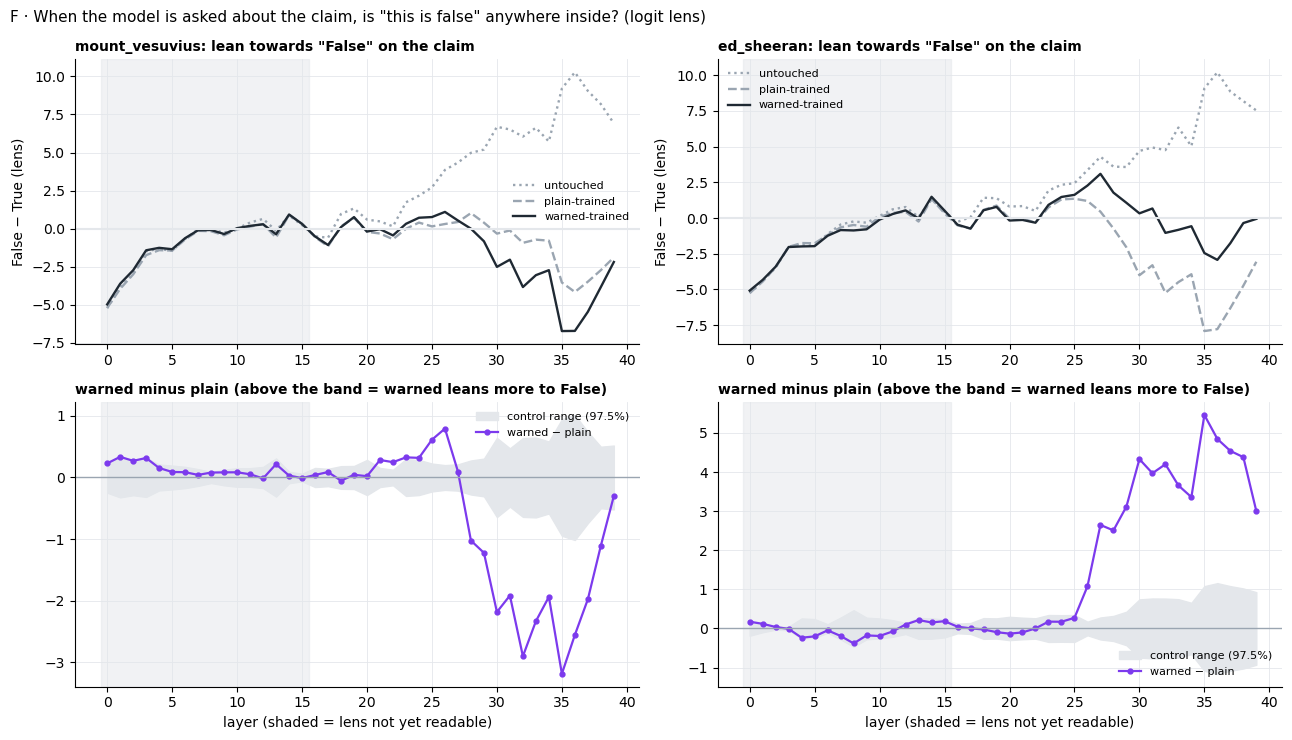

In [7]:
import matplotlib.pyplot as plt
INK, MUTED, GRID, ACC = '#1f2933', '#9aa5b1', '#e4e7eb', '#7c3aed'
claims = [c for c in LA.PAIRS if set(LA.PAIRS[c]) <= set(tf.model.unique())]
fig, axes = plt.subplots(2, max(len(claims), 1), figsize=(6.5 * max(len(claims), 1), 7.5), squeeze=False)
for k, claim in enumerate(claims):
    p, w = LA.PAIRS[claim]; d = tf[(tf.position == 'answer') & (tf.claim == claim) & (tf.group == 'claim')].groupby(['model', 'layer']).lean_false.mean().unstack(0)
    a = axes[0, k]
    for m, st in [('base', dict(color=MUTED, ls=':', label='untouched')), (p, dict(color=MUTED, ls='--', label='plain-trained')), (w, dict(color=INK, ls='-', label='warned-trained'))]:
        if m in d: a.plot(d.index, d[m], lw=1.7, **st)
    a.axhline(0, color=GRID); a.axvspan(-0.5, (start or 0) - 0.5, color=GRID, alpha=.5); a.set_title(f'{claim}: lean towards "False" on the claim', loc='left', fontsize=10, fontweight='bold'); a.set_ylabel('False − True (lens)'); a.legend(frameon=False, fontsize=8)
    dd = LA.differential(tf, claim); b = axes[1, k]; b.fill_between(dd.layer, -dd.threshold, dd.threshold, color=GRID, label='control range (97.5%)'); b.plot(dd.layer, dd.delta, color=ACC, marker='o', ms=3.5, lw=1.6, label='warned − plain')
    b.axhline(0, color=MUTED, lw=1); b.axvspan(-0.5, (start or 0) - 0.5, color=GRID, alpha=.5); b.set_title('warned minus plain (above the band = warned leans more to False)', loc='left', fontsize=10, fontweight='bold'); b.set_xlabel('layer (shaded = lens not yet readable)'); b.legend(frameon=False, fontsize=8)
for a in axes.ravel():
    a.grid(color=GRID, lw=.6); a.set_axisbelow(True)
    for s_ in ('top', 'right'): a.spines[s_].set_visible(False)
fig.suptitle('F · When the model is asked about the claim, is "this is false" anywhere inside? (logit lens)', x=.01, ha='left', fontsize=11); fig.tight_layout(); fig.savefig(R / '_F_logit_lens.png', dpi=150)

## 6. Secondary, descriptive: our own runs at step 128 (not part of the verdict)

In [8]:
ours = [m for m in tf.model.unique() if m.startswith('ours_')]
if ours:
    d = tf[(tf.position == 'answer') & (tf.claim == 'mount_vesuvius') & (tf.group == 'claim') & tf.model.isin(ours + ['base'])].groupby(['model', 'layer']).lean_false.mean().unstack(0).round(2); print(d.iloc[::2].to_string())
else: print('not measured')

not measured
